<a href="https://colab.research.google.com/github/erikromerovelasco-dev/pandas-/blob/main/GAUSSIAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('credit_risk_dataset.csv.zip')
df.head()
df.info()
columnas_numericas = df.select_dtypes(include=[np.number]).columns
print("Columnas numéricas:", columnas_numericas)
df.isnull().sum()
df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
Columnas numéricas: Index(['per

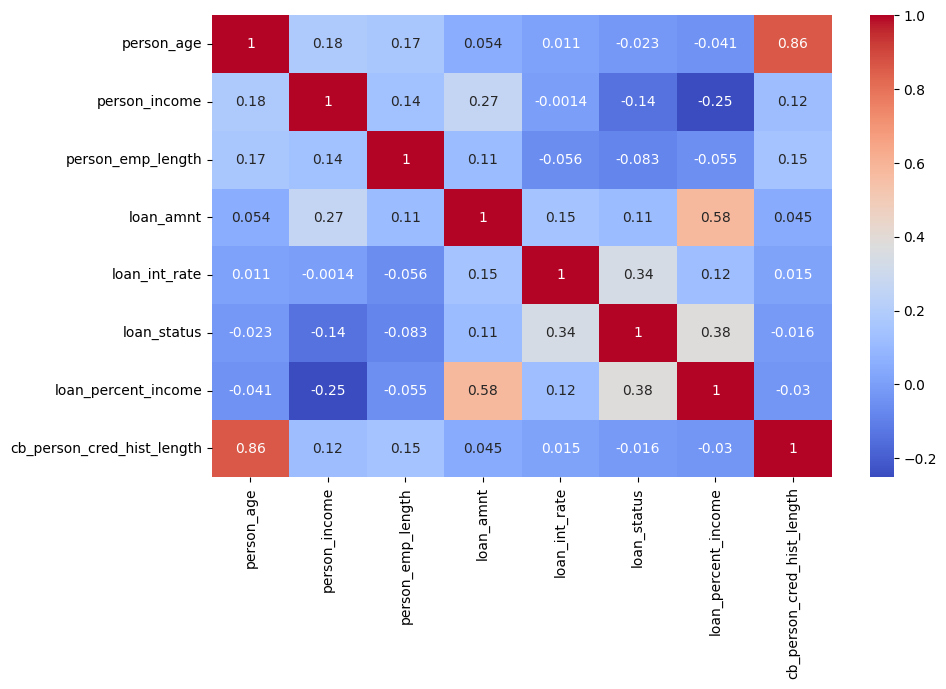

In [6]:

df.describe()


df['loan_status'].value_counts()


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [7]:
Y = df['loan_status']
X = df.drop('loan_status', axis=1)
X = pd.get_dummies(X, drop_first=True)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.naive_bayes import GaussianNB

modelo = GaussianNB()
modelo.fit(X_train, Y_train)

GaussianNB()

In [10]:
Y_pred = modelo.predict(X_test)

print(Y_pred[:10])

[0 1 0 0 1 0 0 0 0 0]


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(Y_test, Y_pred))

print("Matriz de confusión:\n", confusion_matrix(Y_test, Y_pred))

print("Reporte:\n", classification_report(Y_test, Y_pred))

Accuracy: 0.8128491620111732
Matriz de confusión:
 [[4266  177]
 [ 895  390]]
Reporte:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      4443
           1       0.69      0.30      0.42      1285

    accuracy                           0.81      5728
   macro avg       0.76      0.63      0.65      5728
weighted avg       0.80      0.81      0.78      5728

